<a href="https://colab.research.google.com/github/AlanaSampaio/Desafio-Final-Netflix-Movies-and-Tv-Shows/blob/main/Script_projeto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Bootcamp Business Intelligence**
####**Desafio Final : Netflix Movies and Tv Shows**
#####**Squad Dorothy Vaughan**

*   **Etapa 1: Definição do MVP**


Diante do desafio estratégico enfrentado pela Netflix em definir em quais tipos de produções deve investir em 2026 com o objetivo de aumentar a retenção de usuários, o desenvolvimento do projeto girou em torno do questionamento:


***"Quais gêneros a plataforma deve investir em 2026 para aumentar a retenção?"***

Para compreender o comportamento do mercado e apoiar as decisões de investimento, a base principal utilizada foi um dataset público disponibilizado na plataforma [Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows?select=netflix_titles.csv), contendo informações sobre filmes e séries disponíveis na Netflix.




*  Para acessar o documento com a definição completa do MVP, basta clicar [aqui](https://docs.google.com/document/d/15Uwo6B1iXwxZV2Yh0wBN8y4Wv0suOay5r6hIriFOxH0/edit?usp=drive_link).

* As bases de dados necessárias para as etapas a seguir podem acessadas na [pasta](https://drive.google.com/drive/folders/1vF9bu7JW0KujqscSYpXp82Ep0cGS31k1?usp=sharing).




*  **Etapa 2: Diagnóstico e Governança**

Devido ao dataset ter muitos dados faltantes, foi feito um plano de curadoria de dados, resultando na base *netflix_titlespf vf.xlsx*.

O foco foi dado especialmente aos dados de diretores e atores.


*   Os detalhes do que foi feito para completar a base com dados externos podem ser acessados no plano completo, basta clicar [aqui](https://docs.google.com/document/d/1yFpWB-g9_H6ObeNEOdifGj4j8Ho6kspQ-Q72OTnUJCo/edit?usp=drive_link
).


In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import pandas as pd
import sqlite3
import logging
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importação da base de dados originais com muitos dados faltantes
df_f = pd.read_csv('netflix_titles (base original).csv')
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# Importação dos dados completos pós curadoria de dados
df = pd.read_excel('netflix_titlespf vf.xlsx')
df.head()

,show_id,type,title,Rating,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,7250.0,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,"Documentaries,Unknown,Unknown,","As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,0.0,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries,","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,0.0,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,0.0,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV,Unknown,","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,10.0,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Info dos dados sem dados faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   Rating        8807 non-null   float64
 4   director      8807 non-null   object 
 5   cast          8807 non-null   object 
 6   country       8807 non-null   object 
 7   date_added    8807 non-null   object 
 8   release_year  8807 non-null   object 
 9   rating        8807 non-null   object 
 10  duration      8807 non-null   object 
 11  genre         8807 non-null   object 
 12  description   8807 non-null   object 
dtypes: float64(1), object(12)
memory usage: 894.6+ KB


*   **Etapa 3:  Manipulação e Estatística**

Para calcular a correlação entre a data de adição na plataforma e a duração dos títulos no Google Sheets e verificar se os filmes estão ficando mais curtos, foi necessário:

1. Transformar a data de adição no formato datetime;
2. Separar em dois datasets por tipo (Movie e TV Show), com a adição das colunas de duração correspondentes;
3. Remoção de NaN nessas colunas, deixando apenas os pares disponíveis.

######*Obs.: O dataset original tinha 8.807 linhas, a duração tinha 4 valores como "Unknown" e a data de adição tinha 10 valores ausentes. Os dois novos datasets separados ficaram com 6.127 linhas (Movie) e 2.666 linhas (TV Show), totalizando 8.793 linhas.*

Para acessar o Sheets com o cálculo da correlação e o histograma de distribuição de títulos por ano de lançamento, basta clicar [aqui](https://docs.google.com/spreadsheets/d/1MYzaw-E5eh5lqt9PPYVta2Itw6cDTUqYLowsz7LvMd0/edit?usp=drive_link).

In [ ]:
# Remoção de espaços em branco e transformação em
# formato de data (adição da coluna de data sem o "Unknown")
df["date_added_dt"] = pd.to_datetime(df["date_added"].str.strip(),
                                     format="%B %d, %Y", errors="coerce")

In [ ]:
# Separação em dois datasets
df_movies = df[df['type'] == 'Movie'].copy()
df_tv = df[df['type'] == 'TV Show'].copy()

In [ ]:
# Adição das colunas de duração
df_movies['minutes'] = (df_movies['duration'].str.extract(r'(\d+)')[0].astype('Int64'))
df_tv['seasons'] = (df_tv['duration'].str.extract(r'(\d+)')[0].astype('Int64'))

In [ ]:
# Remoção de NaN nas colunas utilizadas na correlação (é preciso que os pares
# estejam completos)
df_movies = df_movies[['release_year', 'date_added_dt', 'minutes']].dropna()
df_tv = df_tv[['release_year', 'date_added_dt', 'seasons']].dropna()

In [ ]:
# Info dos dados
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6127 entries, 0 to 8806
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   release_year   6127 non-null   object        
 1   date_added_dt  6127 non-null   datetime64[ns]
 2   minutes        6127 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(1)
memory usage: 197.5+ KB


In [ ]:
# Info dos dados
df_tv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2666 entries, 1 to 8803
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   release_year   2666 non-null   object        
 1   date_added_dt  2666 non-null   datetime64[ns]
 2   seasons        2666 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(1)
memory usage: 85.9+ KB


In [ ]:
# Exportação das bases com as colunas necessárias
df_movies.to_csv('df_movies_etapa3.csv', index=False)
df_tv.to_csv('df_tv_etapa3.csv', index=False)

Check da correlação calculada no Google Sheets

In [ ]:
# Transforma a data em um número inteiro que representa o tempo
df_movies['date_num'] = df_movies['date_added_dt'].map(pd.Timestamp.toordinal)
df_tv['date_num'] = df_tv['date_added_dt'].map(pd.Timestamp.toordinal)

#####Data de adição

In [ ]:
# Entre a data de adição e a duração dos filmes
corr_movies = (df_movies[['minutes','date_num']].dropna().corr())
print(corr_movies)

          minutes  date_num
minutes   1.00000   0.12525
date_num  0.12525   1.00000


In [ ]:
# Entre a data de adição e a duração das séries em temporadas
corr_tv = (df_tv[['seasons','date_num']].dropna().corr())
print(corr_tv)

           seasons  date_num
seasons   1.000000  0.042311
date_num  0.042311  1.000000


#####Ano de lançamento

In [ ]:
# Entre o ano de lançamento e a duração dos filmes
corr_movies_year = (df_movies[['minutes','release_year']].dropna().corr())
print(corr_movies_year)

               minutes  release_year
minutes       1.000000     -0.209689
release_year -0.209689      1.000000


In [ ]:
# Entre o ano de lançamento e a duração das séries em temporadas
corr_tv_year = (df_tv[['seasons','release_year']].dropna().corr())
print(corr_tv_year)

               seasons  release_year
seasons       1.000000     -0.081404
release_year -0.081404      1.000000


* **Etapa 4: Engenharia SQL Avançada**

A query separa os gêneros (que vêm em uma única string separada por vírgula), além de criar um ranking de gêneros por país.


In [ ]:
df2 = pd.read_csv('netflix_titlespf_vf.csv')
df2.head()

# Cria banco em memória
conn = sqlite3.connect(':memory:')

# Transforma o dataframe em tabela SQL
df2.to_sql('tabela_filmes', conn, index=False, if_exists='replace')

8807

In [ ]:
# Query
query = """
WITH paises_split AS (

    SELECT
        TRIM(SUBSTR(country, 1, INSTR(country || ',', ',') - 1)) AS country,
        Genre
    FROM tabela_filmes

),

generos_por_pais AS (
  SELECT
    country,
    SUBSTR(Genre, 1, INSTR(Genre, ',') - 1) AS genero,
    COUNT(*) AS total
  FROM paises_split
  GROUP BY country, genero
)

SELECT
  g1.country,
  g1.genero,
  g1.total
FROM generos_por_pais g1
LEFT JOIN generos_por_pais g2
  ON g1.country = g2.country
  AND g2.total > g1.total
GROUP BY
  g1.country,
  g1.genero,
  g1.total
HAVING COUNT(g2.genero) < 3
ORDER BY
  g1.country,
  g1.total DESC;
"""

resultado = pd.read_sql_query(query, conn)
resultado.to_csv("ranking_generos_pais.csv", index=False)

In [ ]:
from google.colab import files
files.download("ranking_generos_pais.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Etapa 5: Data Wrangling com Python**

Nesta etapa, o "Mês de lançamento" foi extraído da coluna de data para criar as categorias de "Temporadas" (Primavera, Verão, etc).

In [ ]:
!pip install prefect -q

In [ ]:
os.environ["PREFECT_API_MODE"] = "ephemeral"

In [ ]:
from prefect import flow, task, get_run_logger
# Configuração do logger
logging.basicConfig(
  level=logging.INFO,
  format='%(asctime)s - %(levelname)s - %(message)s',
  filename='pipeline.log',
  filemode='w'
)

logger = logging.getLogger()

# Tratamento de nulos
@task
def tratar_nulos(df):

    logger = get_run_logger()
    logger.info("Tratando valores nulos")

    df = df.fillna({
        'director': 'Não informado',
        'cast': 'Não informado',
        'country': 'Não informado',
        'rating': 'Não informado'
    })

    return df


# Tratamento das datas
@task
def tratar_datas(df):

  logger = get_run_logger()
  logger.info("Iniciando tratamento de datas")

  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

  logger.info("Datas tratadas")

  return df


# Extrair mês
@task
def extrair_mes(df):
  logger = get_run_logger()
  logger.info("Extraindo mês de lançamento")
  df['mes_lancamento'] = df['date_added'].dt.month
  df['nome_mes'] = df['date_added'].dt.month_name()
  df['mes_lancamento'] = df['mes_lancamento'].astype('Int64')

  return df

# Criar temporadas
def criar_temporada(mes):
  if mes in [12,1,2]:
      return "Verão"
  elif mes in [3,4,5]:
      return "Outono"
  elif mes in [6,7,8]:
      return "Inverno"
  elif mes in [9,10,11]:
      return "Primavera"
  else:
      return None

@task
def adicionar_temporadas(df):
  logger = get_run_logger()
  logger.info("Criando categorias de temporada")
  df['temporada'] = df['mes_lancamento'].apply(criar_temporada)
  return df


# Tratamento da duração
@task
def tratar_duracao(df):

    logger = get_run_logger()
    logger.info("Tratando duração")
    df['duracao_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
    df['tipo_duracao'] = df['duration'].str.extract(r'(min|Season|Seasons)')
    return df

# Criar década
@task
def criar_decada(df):
    logger = get_run_logger()
    logger.info("Criando coluna década")
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
    df['decada'] = (df['release_year'] // 10) * 10

    return df


# Contar atores
@task
def contar_atores(df):
    logger = get_run_logger()
    logger.info("Contando número de atores")
    df['num_atores'] = df['cast'].apply(
        lambda x: len(x.split(',')) if x != "Não informado" else 0
    )
    return df

# Separar países
@task
def separar_paises(df):
    logger = get_run_logger()
    logger.info("Separando países")
    df['country'] = df['country'].str.split(',')

    return df

# Normalizar gêneros
@task
def normalizar_generos(df):

    logger = get_run_logger()
    logger.info("Normalizando gêneros")

    df_generos = df.melt(
        id_vars=['show_id','country'],
        value_vars=['genre1','genre2','genre3'],
        value_name='genre'
    )

    df_generos = df_generos.dropna(subset=['genre'])

    return df_generos


# FLOW PRINCIPAL
@flow
def pipeline_etl(df):

  logger = get_run_logger()
  logger.info("Pipeline iniciado")
  df = tratar_nulos(df)
  df = tratar_datas(df)
  df = extrair_mes(df)
  df = adicionar_temporadas(df)
  df = tratar_duracao(df)
  df = criar_decada(df)
  df = contar_atores(df)
  df = separar_paises(df)
  logger.info("Pipeline finalizado")
  return df


df_final = pipeline_etl(df)

df_final.to_csv('netflix_tratado.csv', index=False)

df_final.head()

INFO:prefect:Starting temporary server on http://127.0.0.1:8188
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.
INFO:prefect.flow_runs:Beginning flow run 'knowing-baboon' for flow 'pipeline-etl'
INFO:prefect.flow_runs:Pipeline iniciado
INFO:prefect.task_runs:Tratando valores nulos
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Iniciando tratamento de datas
INFO:prefect.task_runs:Datas tratadas
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Extraindo mês de lançamento
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Criando categorias de temporada
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Tratando duração
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Criando coluna década
INFO:prefect.task_runs:Finished in state Completed()
INFO:prefect.task_runs:Contando número de ato

,show_id,type,title,Rating,director,cast,country,date_added,release_year,rating,...,genre,description,date_added_dt,mes_lancamento,nome_mes,temporada,duracao_num,tipo_duracao,decada,num_atores
0,s1,Movie,Dick Johnson Is Dead,7250.0,Kirsten Johnson,Unknown,[United States],2021-09-25,2020.0,PG-13,...,"Documentaries,Unknown,Unknown,","As her father nears the end of his life, filmm...",2021-09-25,9,September,Primavera,90.0,min,2020.0,1
1,s2,TV Show,Blood & Water,0.0,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021.0,TV-MA,...,"International TV Shows, TV Dramas, TV Mysteries,","After crossing paths at a party, a Cape Town t...",2021-09-24,9,September,Primavera,2.0,Season,2020.0,19
2,s3,TV Show,Ganglands,0.0,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[Unknown],2021-09-24,2021.0,TV-MA,...,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,9,September,Primavera,1.0,Season,2020.0,9
3,s4,TV Show,Jailbirds New Orleans,0.0,Unknown,Unknown,[Unknown],2021-09-24,2021.0,TV-MA,...,"Docuseries, Reality TV,Unknown,","Feuds, flirtations and toilet talk go down amo...",2021-09-24,9,September,Primavera,1.0,Season,2020.0,1
4,s5,TV Show,Kota Factory,10.0,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021.0,TV-MA,...,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021-09-24,9,September,Primavera,2.0,Season,2020.0,8


**A Etapa 6 foi a criação e um dashboard de Análise de Portfólio em Power BI. Para visualização dos dados, basta clicar aqui. (INSERIR LINK DO BI PUBLICADO)**

**Etapa 7: Storytelling**

Nesta etapa foi criada uma matriz de correlação para agrupar filmes semelhantes com base na duração e classificação indicativa.


*   O pitch final apresentado foi focado em como otimizar o catálogo para o público brasileiro.

In [ ]:
# Dados dos filmes, já tratados
df_movies = df_final[df_final['type'] == 'Movie'].copy()

# Grupos de classificação para facilitar a análise
rating_map = {
    'TV-Y': '1. Livre (0+)', 'TV-Y7': '1. Livre (0+)', 'TV-Y7-FV': '1. Livre (0+)', 'TV-G': '1. Livre (0+)', 'G': '1. Livre (0+)', 'PG': '1. Livre (0+)',
    'TV-PG': '2. Infanto-juvenil (10+)',
    'PG-13': '3. Adolescente (13-17)', 'TV-14': '3. Adolescente (13-17)', 'R': '3. Adolescente (13-17)',
    'TV-MA': '4. Adulto (18+)', 'NC-17': '4. Adulto (18+)'
}
df_movies['Grupo_Classificacao'] = df_movies['rating'].map(rating_map)

# Função para separar os filmes por duração
def classificar_duracao(minutos):
    if minutos < 90: return 'A. Curto (< 90 min)'
    elif minutos <= 120: return 'B. Médio (90-120 min)'
    else: return 'C. Longo (> 120 min)'

df_movies['Faixa_Duracao'] = df_movies['duracao_num'].apply(classificar_duracao)

# Extrai apenas o primeiro gênero (para simplificar)
df_movies['genero_principal'] = df_movies['genre'].str.split(',').str[0].str.strip()

# Cria a tabela para o heatmap
matriz = pd.crosstab(df_movies['Grupo_Classificacao'], df_movies['Faixa_Duracao'])

# Função para extrair os principais gêneros de cada grupo
def get_top_genres(classif, dur):
    subset = df_movies[(df_movies['Grupo_Classificacao'] == classif) & (df_movies['Faixa_Duracao'] == dur)]
    top = subset['genero_principal'].value_counts().head(3).reset_index()
    top.columns = ['Gênero', 'Quantidade']
    top['Segmento'] = f"{classif.split('.')[-1].strip()}"
    return top

# Extrai gêneros mais comuns de adolescente e adulto (duração média)
df_plot_generos = pd.concat([
    get_top_genres('3. Adolescente (13-17)', 'B. Médio (90-120 min)'),
    get_top_genres('4. Adulto (18+)', 'B. Médio (90-120 min)')
])

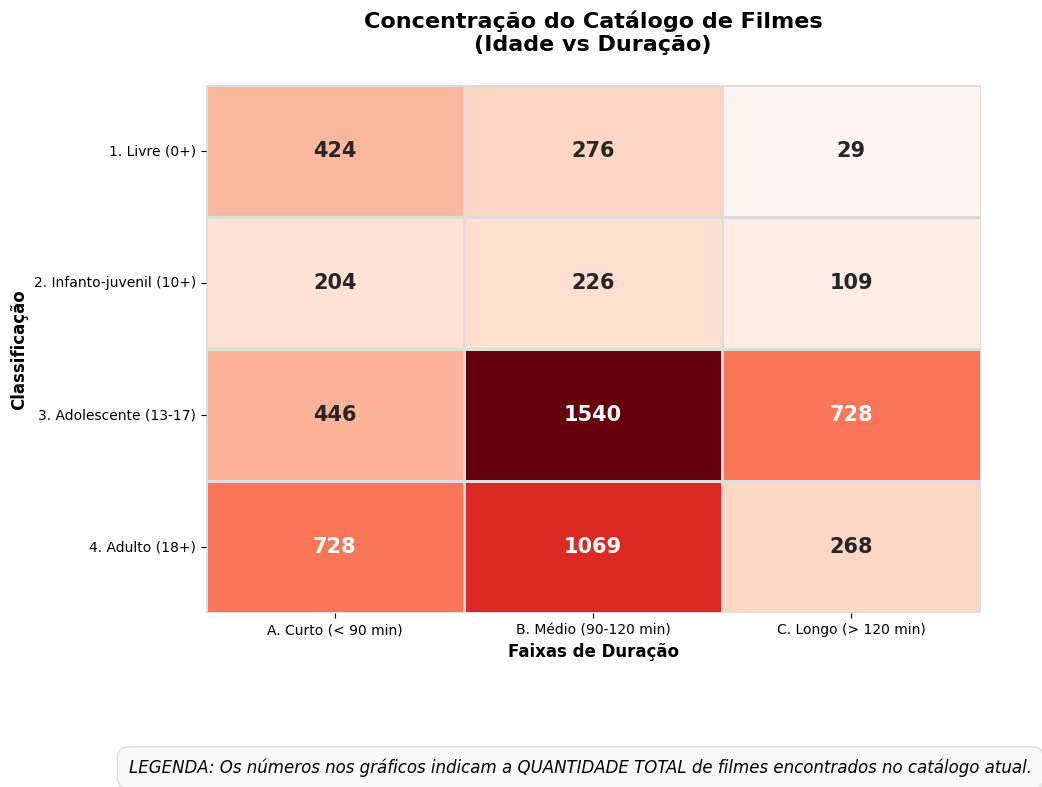

In [ ]:
# ==========================================
# 1. HEATMAP (COM LEGENDA)
# ==========================================
plt.figure(figsize=(10, 8), facecolor='white')

sns.heatmap(matriz, annot=True, fmt='d', cmap='Reds', linewidths=2, linecolor='#dddddd', cbar=False,
            annot_kws={"size": 15, "weight": "bold"})

plt.title("Concentração do Catálogo de Filmes\n(Idade vs Duração)", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Classificação", fontweight='bold', fontsize=12)
plt.xlabel("Faixas de Duração", fontweight='bold', fontsize=12)
plt.yticks(rotation=0)

# legenda em caixa centralizada (igual ao original)
plt.figtext(
    0.5, 0.02,
    "LEGENDA: Os números nos gráficos indicam a QUANTIDADE TOTAL de filmes encontrados no catálogo atual.",
    ha="center",
    fontsize=12,
    style='italic',
    bbox=dict(facecolor='#f9f9f9', edgecolor='#dddddd', boxstyle='round,pad=0.7')
)

plt.subplots_adjust(bottom=0.22)

plt.savefig("heatmap_filmes.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

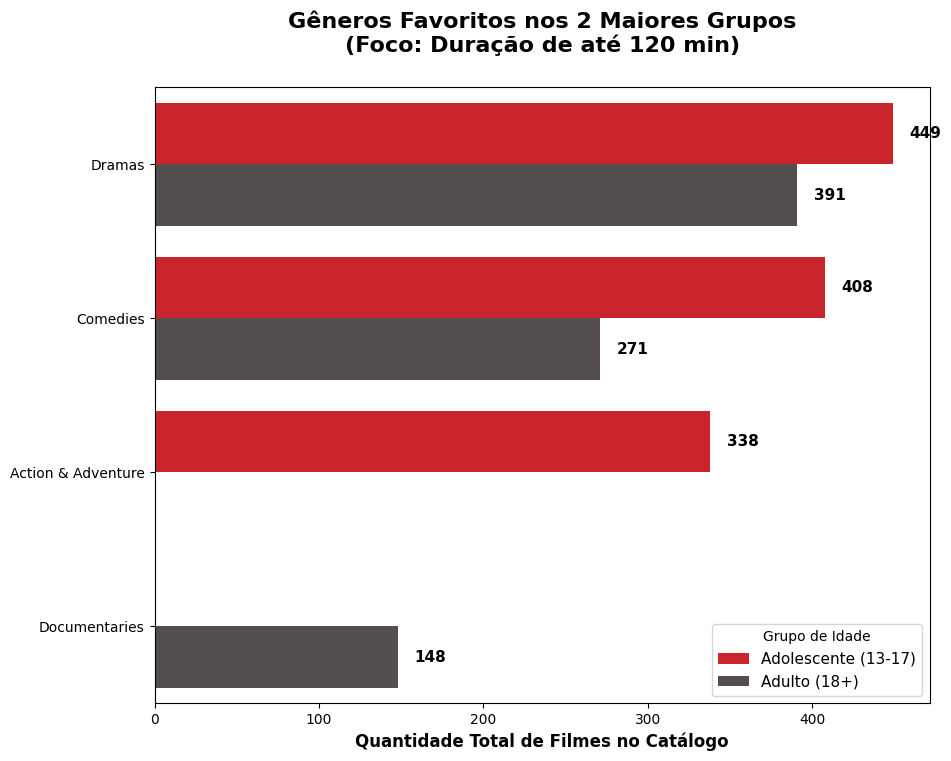

In [ ]:
# ==========================================
# 2. GRÁFICO DE BARRAS
# ==========================================
plt.figure(figsize=(10, 8), facecolor='white')

ax = sns.barplot(x='Quantidade', y='Gênero', hue='Segmento',
                 data=df_plot_generos, palette=['#e50914', '#564d4d'])

plt.title("Gêneros Favoritos nos 2 Maiores Grupos\n(Foco: Duração de até 120 min)", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Quantidade Total de Filmes no Catálogo", fontweight='bold', fontsize=12)
plt.ylabel("")
plt.legend(title='Grupo de Idade', fontsize=11)

# adicionar os valores nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 10, p.get_y() + p.get_height()/2,
                f'{int(width)}', va='center', fontweight='bold', fontsize=11)

plt.savefig("grafico_generos.png", dpi=300, facecolor='white', bbox_inches='tight')
plt.show()